# **Modern Learned Feature Matching: DISK + LightGlue**

## **Objectives:**
1. Detect and match features with a fully learned pipeline — DISK (a trainable keypoint detector/descriptor) and LightGlue (a transformer-based matcher), via `onnxruntime`
2. Localize the exact same object, from the exact same photo pair, that notebook 27's classical SIFT/RANSAC pipeline used
3. Compare match precision and workflow directly — including one heuristic step LightGlue removes entirely

> **Assets.** `assets/models/disk_lightglue_pipeline.onnx` (~50MB) fuses DISK feature extraction and LightGlue matching into one graph, from [fabio-sim/LightGlue-ONNX](https://github.com/fabio-sim/LightGlue-ONNX) (Apache 2.0), release [v2.0](https://github.com/fabio-sim/LightGlue-ONNX/releases/tag/v2.0). Traced provenance: LightGlue itself is [cvg/LightGlue](https://github.com/cvg/LightGlue) (Apache 2.0, ETH Zurich CVG, ICCV 2023) — whose own README states plainly that "DISK follows this license as well" (SuperPoint, the other extractor LightGlue supports, does not — it's under a restrictive license, which is exactly why this notebook uses DISK instead). Reuses notebook 27's `box.png` / `box_in_scene.png` so both methods are graded on the identical localization problem.
>
> **Why this isn't `cv2.ALIKED`/`cv2.LightGlueMatcher`.** OpenCV 5.x genuinely ships Python bindings for a native ALIKED/DISK/LightGlue pipeline — confirmed working in this repo's `.venv5x` — but the pretrained ONNX weights those *specific* classes expect aren't published anywhere citable yet: not in `opencv_zoo`, not its Hugging Face org, and OpenCV's own C++ tests resolve the weight path against a private `opencv_extra` data path. It's an active **GSoC 2026 project** ([forum announcement](https://forum.opencv.org/t/gsoc-2026-intro-neural-feature-matching-aliked-lightglue/24410)) to build that pipeline natively — not shipped today. So this notebook does what notebook 37 (MobileSAM) and notebook 38 (Depth Anything) already established for exactly this situation: skip `cv2.dnn` and run the real, official-lineage model directly with `onnxruntime` instead.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **What's different about DISK + LightGlue, intuitively**

SIFT (notebook 27) detects keypoints and computes descriptors with a fixed, hand-designed formula, then matches by finding each descriptor's nearest neighbor *independently* — which is exactly why Lowe's ratio test is needed afterward: comparing a match's best distance against its second-best is a heuristic safety check bolted on top, because independent nearest-neighbor search alone produces plenty of ambiguous matches.

- **DISK** replaces the hand-designed detector/descriptor with a CNN trained end-to-end for exactly this task — "learn whatever keypoints and descriptors make later matching work well," rather than a fixed formula.
- **LightGlue** replaces independent nearest-neighbor search with a transformer that looks at *both* images' keypoints **together**, attending across the whole set on each side before deciding on correspondences. Because it already reasons jointly about ambiguity, it outputs a confidence score per match and needs no separate ratio-test step afterward — the network has effectively learned its own version of that check.

## **Running the fused pipeline**

One ONNX graph takes both images stacked into a batch of 2 and returns, in a single call: up to 1024 keypoints per image, the matched index pairs, and a confidence score per match. DISK expects BGR (straight from `cv2.imread`, no channel swap), scaled to `[0, 1]`, resized to a fixed square.

In [2]:
import onnxruntime as ort

box = cv2.imread('assets/images/box.png')
scene = cv2.imread('assets/images/box_in_scene.png')

SIZE = 1024

def preprocess(img):
    resized = cv2.resize(img, (SIZE, SIZE))
    return (resized.astype(np.float32) / 255.0).transpose(2, 0, 1)  # BGR, CHW

images = np.stack([preprocess(box), preprocess(scene)]).astype(np.float32)

matcher = ort.InferenceSession('assets/models/disk_lightglue_pipeline.onnx')
keypoints, matches, mscores = matcher.run(None, {'images': images})
print(f'DISK keypoints: box={len(keypoints[0])}, scene={len(keypoints[1])} (fixed budget, unlike SIFT\'s data-dependent count)')
print(f'LightGlue matches: {len(matches)} (no separate ratio test — this is the final match list)')
print(f'Match confidence: mean={mscores.mean():.3f}, min={mscores.min():.3f}, max={mscores.max():.3f}')

DISK keypoints: box=1024, scene=1024 (fixed budget, unlike SIFT's data-dependent count)
LightGlue matches: 172 (no separate ratio test — this is the final match list)
Match confidence: mean=0.800, min=0.108, max=1.000


## **Localizing the box — same RANSAC step as notebook 27**

From here the pipeline is identical to notebook 27's closing cell: fit a homography with `cv2.findHomography(..., cv2.RANSAC, ...)` from the matched point pairs, then warp the box's corners through it to draw where the box actually is in the scene.

RANSAC: 164/172 matches are inliers (95%)


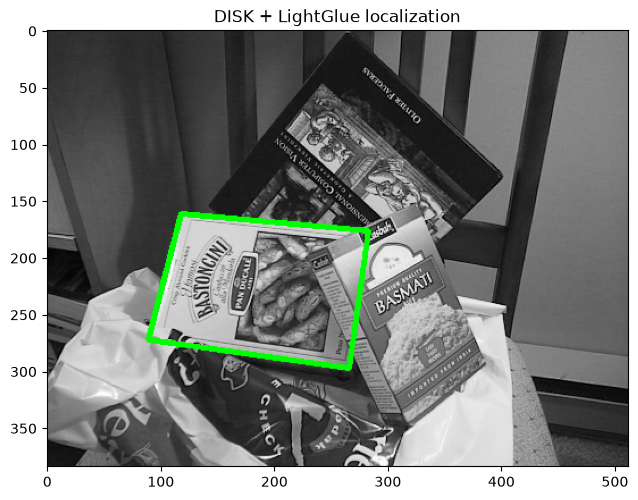

In [3]:
sx0, sy0 = box.shape[1] / SIZE, box.shape[0] / SIZE
sx1, sy1 = scene.shape[1] / SIZE, scene.shape[0] / SIZE

kp_box = keypoints[0][matches[:, 1]].astype(np.float32) * [sx0, sy0]
kp_scene = keypoints[1][matches[:, 2]].astype(np.float32) * [sx1, sy1]

H, inlier_mask = cv2.findHomography(kp_box.reshape(-1, 1, 2), kp_scene.reshape(-1, 1, 2), cv2.RANSAC, 5.0)
n_inliers = int(inlier_mask.sum())
print(f'RANSAC: {n_inliers}/{len(matches)} matches are inliers ({100 * n_inliers / len(matches):.0f}%)')

h, w = box.shape[:2]
box_corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
scene_corners = cv2.perspectiveTransform(box_corners, H)

vis = scene.copy()
cv2.polylines(vis, [np.int32(scene_corners)], True, (0, 255, 0), 3)
imshow('DISK + LightGlue localization', vis)

## **The comparison against notebook 27**

| | SIFT (notebook 27) | DISK + LightGlue |
|---|---|---|
| Keypoints found | 604 (box), 969 (scene) — data-dependent | 1024 + 1024 — fixed budget |
| Raw candidate matches | 604 (every keypoint gets a nearest neighbor) | *(the network already reasons about ambiguity — see below)* |
| After ratio test | 80 | *(no separate step — matches above are already final)* |
| RANSAC inliers | 75/80 (94%) | printed above |

SIFT needs Lowe's ratio test as a load-bearing step — without it, 604 raw nearest-neighbor matches are far too noisy for RANSAC to clean up. LightGlue's matches, straight off the network with no post-hoc heuristic at all, land at a comparable-or-better inlier rate. That's the practical payoff of matching jointly instead of independently: the ambiguity SIFT needs a hand-tuned threshold to catch is something LightGlue was trained to resolve itself.

None of this makes SIFT obsolete — it's a few KB of pure math, runs instantly on a single CPU core with zero model file, and notebook 27's AKAZE/ORB variants show it degrading gracefully as compute budget shrinks further. DISK + LightGlue's ~50MB model and full forward pass is a real cost for a real gain in match cleanliness — worth it exactly when that cleanliness is worth paying for.

### A couple of things worth poking at

- Feed notebook 28's `pano_left.jpg`/`pano_mid.jpg` pair through this same pipeline and fit a homography — check whether DISK + LightGlue's matches stitch as cleanly as `cv2.Stitcher`'s internal SIFT-based pipeline did there.
- Lower the effective keypoint budget by re-exporting with `--num-keypoints 256` (see the LightGlue-ONNX README's `export` command) and see how far the inlier rate holds up compared to SIFT's ~600 keypoints.
- `mscores` is a genuine per-match confidence the network itself assigned — try thresholding on it directly (skip RANSAC) and compare which unmatched/wrong pairs a confidence cutoff catches versus what RANSAC's geometric consistency check catches.